##Import library

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

from tensorflow.keras.datasets import mnist
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Dropout
from tensorflow.keras.layers import Flatten, Dense
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.optimizers import Adam, Adadelta, SGD

##Load and Preprocess MNIST

In [ ]:
# Load data
(x_train, y_train), (x_test, y_test) = mnist.load_data()

# Normalize (0–255 → 0–1)
x_train = x_train.astype('float32') / 255
x_test = x_test.astype('float32') / 255

# Add channel dimension (28x28 → 28x28x1)
x_train = np.expand_dims(x_train, axis=-1)
x_test = np.expand_dims(x_test, axis=-1)

# One-hot encode labels
y_train = to_categorical(y_train, 10)
y_test = to_categorical(y_test, 10)

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


##Build the CNN Model

In [ ]:
def build_model():
    model = Sequential()

    # Conv Layer 1
    model.add(Conv2D(64, (3,3), strides=(2,2),
                     padding='valid', activation='relu',
                     input_shape=(28,28,1)))

    # Conv Layer 2
    model.add(Conv2D(32, (2,2), strides=(1,1),
                     padding='same', activation='relu'))

    # Max Pool
    model.add(MaxPooling2D(pool_size=(2,2), strides=(1,1)))

    # Dropout
    model.add(Dropout(0.35))

    # Flatten
    model.add(Flatten())

    # Dense
    model.add(Dense(256, activation='tanh'))

    # Dropout
    model.add(Dropout(0.5))

    # Output Layer
    model.add(Dense(10, activation='softmax'))

    return model

##Train with Different Optimizers

In [ ]:
optimizers = {
    "Adam": Adam(),
    "Adadelta": Adadelta(),
    "SGD": SGD()
}

history_dict = {}

for name, opt in optimizers.items():
    print(f"\nTraining with {name} optimizer")

    model = build_model()
    model.compile(optimizer=opt,
                  loss='categorical_crossentropy',
                  metrics=['accuracy'])

    history = model.fit(
        x_train, y_train,
        validation_data=(x_test, y_test),
        epochs=10,
        batch_size=128,
        verbose=1
    )

    history_dict[name] = history


Training with Adam optimizer


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 51s 104ms/step - accuracy: 0.9451 - loss: 0.1827 - val_accuracy: 0.9831 - val_loss: 0.0525
Epoch 2/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 81s 102ms/step - accuracy: 0.9783 - loss: 0.0686 - val_accuracy: 0.9867 - val_loss: 0.0382
Epoch 3/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 84s 106ms/step - accuracy: 0.9820 - loss: 0.0565 - val_accuracy: 0.9894 - val_loss: 0.0330
Epoch 4/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 81s 103ms/step - accuracy: 0.9852 - loss: 0.0462 - val_accuracy: 0.9898 - val_loss: 0.0301
Epoch 5/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 50s 106ms/step - accuracy: 0.9875 - loss: 0.0387 - val_accuracy: 0.9904 - val_loss: 0.0310
Epoch 6/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 50s 106ms/step - accuracy: 0.9886 - loss: 0.0365 - val_accuracy: 0.9905 - val_loss: 0.0308
Epoch 7/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 48s 102ms/step - accuracy: 0.9898 - loss: 0.0319 - val_accuracy: 0.9917 - val_loss: 0.0282
Epoch 8/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 83s 105ms/step - accuracy: 0.9905 - loss: 0

##Evaluate Model Performance

In [8]:
from tensorflow.keras.optimizers import Adam, Adadelta, SGD

for name, history in history_dict.items():
    print(f"\nEvaluating model with {name}")

    model = build_model()

    # Create a new optimizer instance for each model
    if name == "Adam":
        current_optimizer = Adam()
    elif name == "Adadelta":
        current_optimizer = Adadelta()
    elif name == "SGD":
        current_optimizer = SGD()
    else:
        raise ValueError(f"Optimizer {name} not recognized for re-instantiation.")

    model.compile(optimizer=current_optimizer,
                  loss='categorical_crossentropy',
                  metrics=['accuracy'])

    model.fit(x_train, y_train, epochs=10, batch_size=128, verbose=0)

    loss, acc = model.evaluate(x_test, y_test, verbose=0)
    print(f"{name} Test Accuracy: {acc:.4f}")


Evaluating model with Adam


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Adam Test Accuracy: 0.9906

Evaluating model with Adadelta
Adadelta Test Accuracy: 0.7979

Evaluating model with SGD
SGD Test Accuracy: 0.9755


##Plot Accuracy Curves

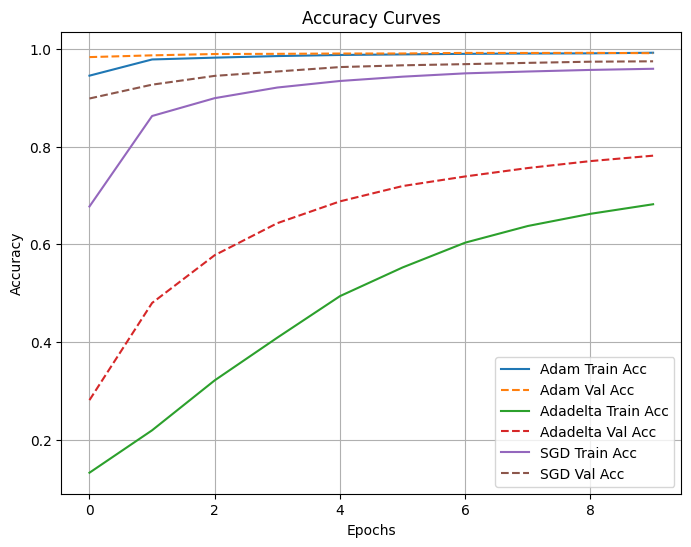

In [9]:
plt.figure(figsize=(8,6))

for name, history in history_dict.items():
    plt.plot(history.history['accuracy'], label=f"{name} Train Acc")
    plt.plot(history.history['val_accuracy'], linestyle='--',
             label=f"{name} Val Acc")

plt.title("Accuracy Curves")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()
plt.grid()

plt.show()

##Confusion Matrix

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step


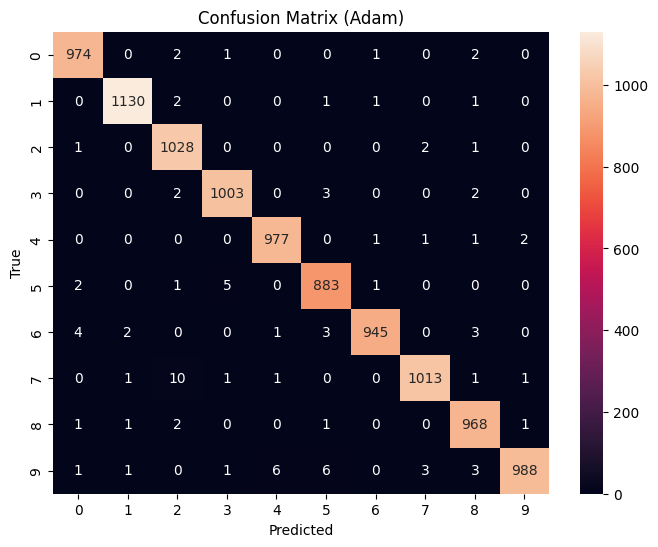

In [11]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

# Use best model (example: Adam)
model = build_model()
model.compile(optimizer=Adam(),
              loss='categorical_crossentropy',
              metrics=['accuracy'])

model.fit(x_train, y_train, epochs=10, batch_size=128, verbose=0)

# Predict
y_pred = model.predict(x_test)
y_pred_classes = np.argmax(y_pred, axis=1)
y_true = np.argmax(y_test, axis=1)

cm = confusion_matrix(y_true, y_pred_classes)

# Plot
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d')
plt.title("Confusion Matrix (Adam)")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()

##Show Some Predictions

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step


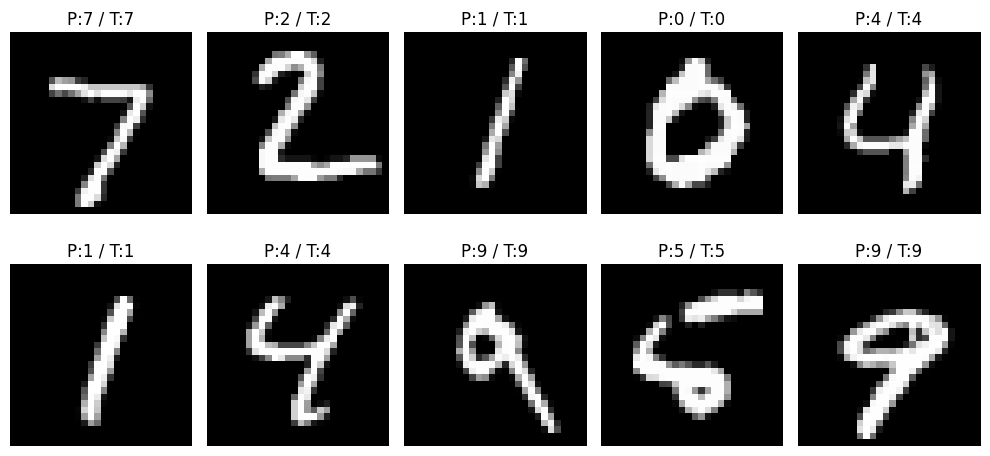

In [12]:
plt.figure(figsize=(10,5))

for i in range(10):
    plt.subplot(2,5,i+1)
    plt.imshow(x_test[i].reshape(28,28), cmap='gray')

    pred = np.argmax(model.predict(x_test[i].reshape(1,28,28,1)))
    true = np.argmax(y_test[i])

    plt.title(f"P:{pred} / T:{true}")
    plt.axis('off')

plt.tight_layout()
plt.show()